<a href="https://colab.research.google.com/github/Tarun-619/ML-lab-1WA23CS015/blob/main/ML_lab_9_(K_means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

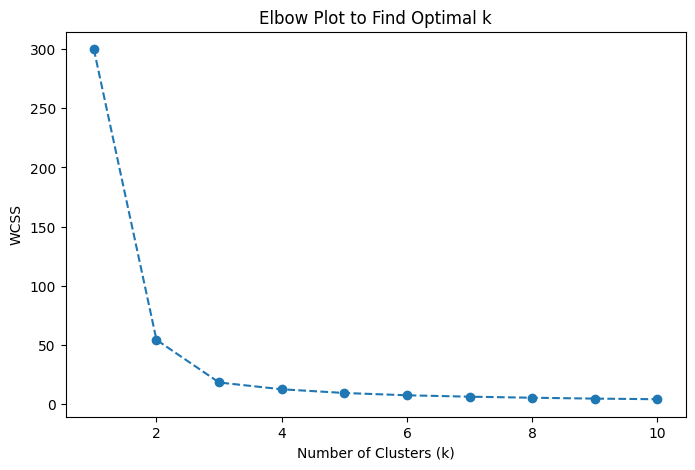

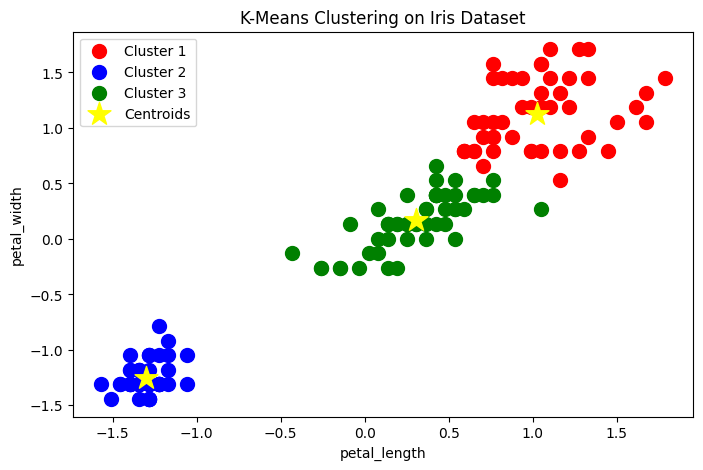

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("iris.csv")

cols_lower = df.columns.astype(str).str.lower()
try:
    petal_length_col = df.columns[cols_lower.str.contains('petal') & cols_lower.str.contains('length')][0]
    petal_width_col = df.columns[cols_lower.str.contains('petal') & cols_lower.str.contains('width')][0]
except IndexError:
    raise KeyError("Could not automatically find the petal columns. Please verify your CSV headers.")

X = df[[petal_length_col, petal_width_col]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Plot to Find Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', marker='*', label='Centroids')
plt.title('K-Means Clustering on Iris Dataset')
plt.xlabel(petal_length_col)
plt.ylabel(petal_width_col)
plt.legend()
plt.show()